In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt


In [8]:
#open cv
I1= cv2.imread('bobi.jpg')
#dimensoes
print(I1.shape)
#data type
print(I1.dtype)

I2= plt.imread('bobi.jpg')
#dimensoes
print(I2.shape)
#data type
print(I2.dtype)

(887, 736, 3)
uint8
(887, 736, 3)
uint8


(np.float64(-0.5), np.float64(735.5), np.float64(886.5), np.float64(-0.5))

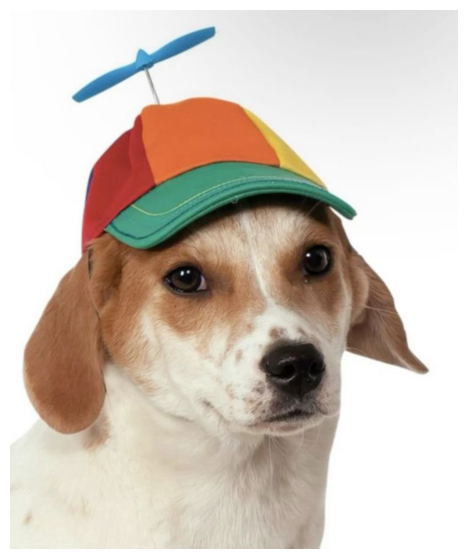

In [10]:
#atribuir nome a figura
cv2.namedWindow('Bobi',1)
cv2.imshow('Bobi',I1)
while True:
    cvKey=cv2.waitKey(10)
    if cvKey == 27:
        cv2.destroyAllWindows()
        break
plt.figure(figsize=(7,7))
plt.imshow(I2)
plt.axis('off')

0 255


(np.float64(-0.5), np.float64(735.5), np.float64(886.5), np.float64(-0.5))

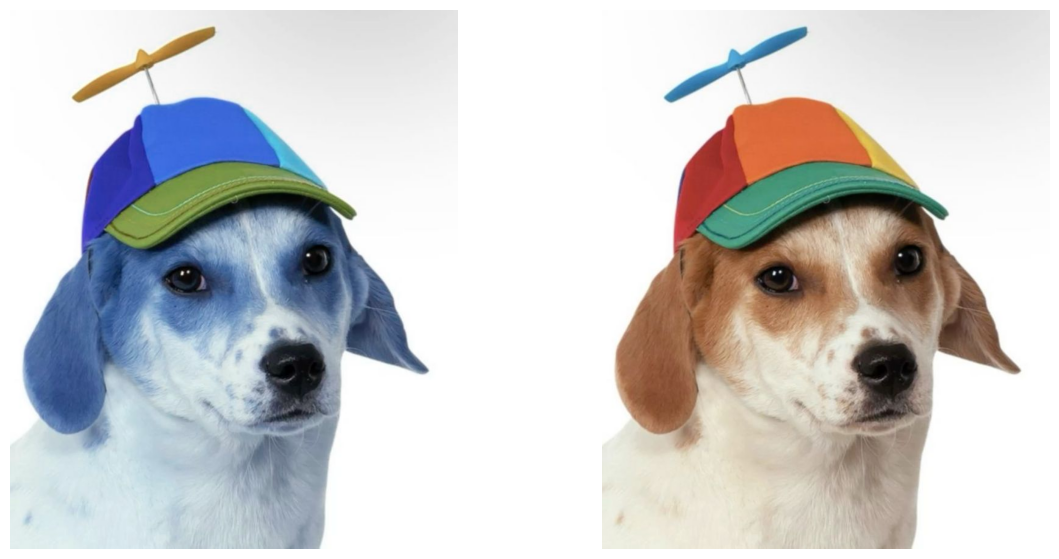

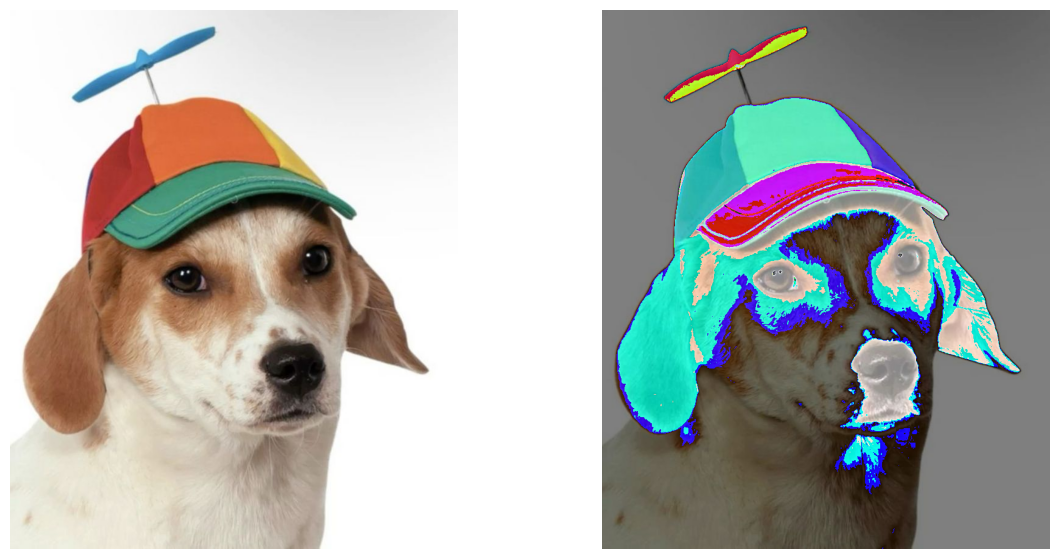

In [ ]:
#ler uma biblioteca e vizualizar com outra
Ia=cv2.imread("bobi.jpg")
#converter BGR para RGB
Ib= cv2.cvtColor(Ia, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14,7))
plt.subplot(121)
plt.imshow(Ia)
plt.axis('off')
plt.subplot(122)
plt.imshow(Ib)
plt.axis('off')

## outra cena

#uint8 numeros entre 0 e 255
#se somarmos uma constante a imagem nao altera gama
plt.figure(figsize=(14,7))
plt.subplot(121)
plt.imshow(Ib)
plt.axis('off')
plt.subplot(122)
Ic= Ib+128
print(Ic.min(), Ic.max())
plt.imshow(Ic)
plt.axis('off')


(np.float64(-0.5), np.float64(735.5), np.float64(886.5), np.float64(-0.5))

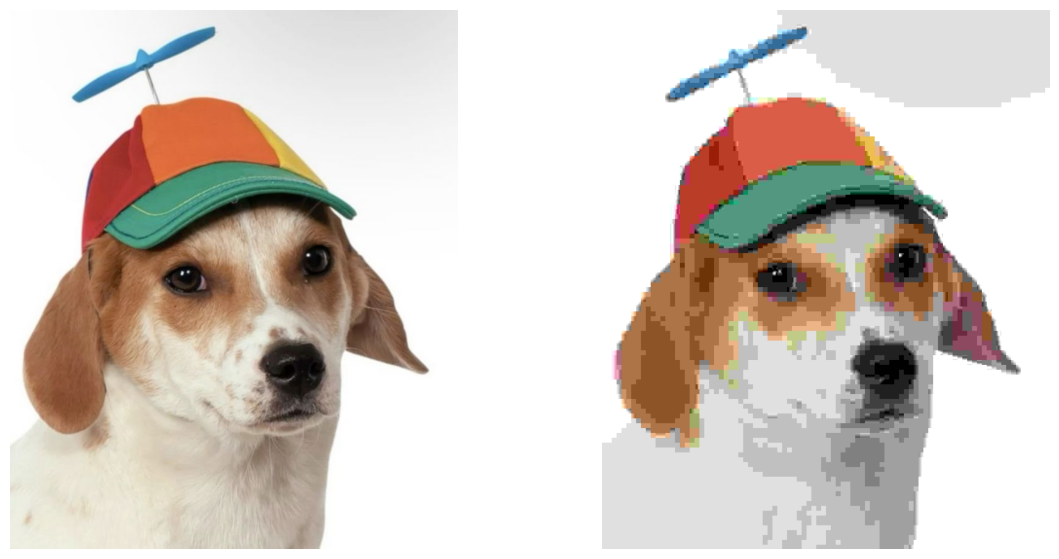

In [4]:
I= cv2.imread("bobi.jpg")
qual= 1
cv2.imwrite('bobi_q%d.jpeg'%qual,I,(cv2.IMWRITE_JPEG_QUALITY,qual))
#ver com matplotlib
Ia=plt.imread('bobi.jpg')
Ib=plt.imread('bobi_q%d.jpeg'%qual)
plt.figure(figsize=(14,7))
plt.subplot(121)
plt.imshow(Ia)
plt.axis('off')
plt.subplot(122)
plt.imshow(Ib)
plt.axis('off')

In [ ]:
## tamanho das imagens
Size_org= os.path.getsize('bobi.jpg')
Size_jpg = os.path.getsize('bobi_q%d.jpeg'%qual)
print('Tamanho original: ', Size_org)
print('Tamanho da imagem jpeg: ', Size_jpg)

Tamanho original:  48842
Tamanho da imagem jpg:  11855


In [15]:
#necessario converter a imagem para float
MSE= np.mean((Ia-Ib)**2)
print('erro quadratico medio : %.2f'%MSE, 'valor mal calculado! D:')
#agora bem feito
Ic= Ia*1.
Id= Ib*1.
MSE= np.mean((Ic-Id)**2)
print('erro quadratico medio : %.2f' %MSE)

erro quadratico medio : 63.65 valor mal calculado! D:
erro quadratico medio : 191.88


In [ ]:
MAE = np.mean(np.abs(Ia-Ib))

In [16]:
##potencia do sinal porg
## potencia do erro perr

Porg=np.mean(Ic**2)
Perr=np.mean((Ic-Id)**2)
SNR=10*np.log10(Porg/Perr)
print('SNR (dBs):',SNR)


SNR (dBs): 23.41628791807787


In [ ]:
##psnr dBs
pSNR= 10*np.log10(255**2/Perr)
print('PSNR (dBs): ', pSNR)


PSNR (dBs):  25.30042785089219


(np.float64(-0.5), np.float64(735.5), np.float64(886.5), np.float64(-0.5))

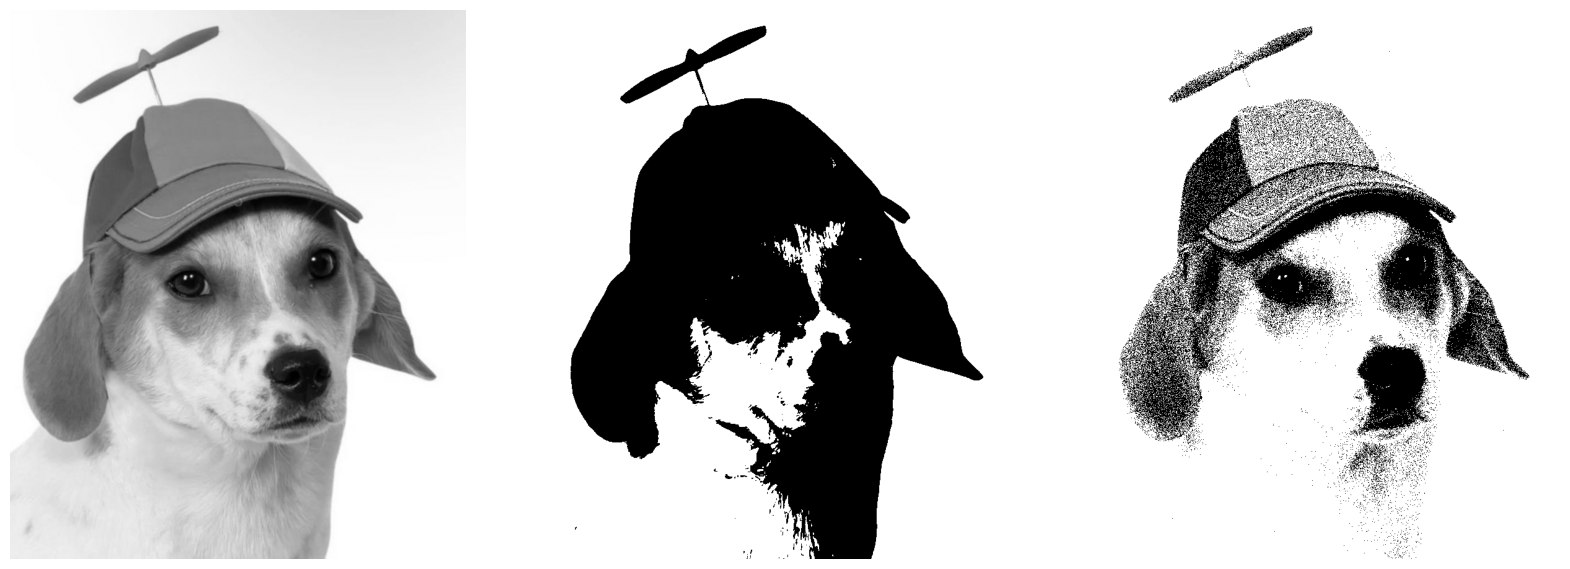

In [12]:
I=cv2.imread('bobi.jpg',0)

#limar fixo e 128 ou media dos pixeis
limFixo=I.mean()
Il=(255*(I>limFixo).astype('uint8'))

#limar aleatorio gerado com ruido guassiano
cnst=2.0
R=np.random.randn(I.shape[0],I.shape[1])*cnst
R=R-R.min()# normalizar
R=R/R.max()#R [0,1] centrado a +-0.5
I2=(255*((I/I.max())>R)).astype('uint8')

plt.figure(figsize=(20,10))
plt.subplot(131)
plt.imshow(I,cmap='gray')
plt.axis('off')

plt.subplot(132)
plt.imshow(Il,cmap='gray')
plt.axis('off')

plt.subplot(133)
plt.imshow(I2,cmap='gray')
plt.axis('off')

In [ ]:
np.unique(I1)
# identifica todos os valores que tem na imagem 

In [ ]:
import numpy.random as rd
import cv2
#defenir o video source(camara e tipicamente 0 ou 1)

video_src=0
capVid = cv2.VideoCapture(video_src)
#ver se foi inicializado correctamente
while(not(capVid.isOpened)):
    capVid = cv2.VideoCapture(video_src)

#ver dimensoes da janela
#.get(n) n de 0 a 18 
print('Imagens de video sao ',capVid.get(3),'x',capVid.get(4),'pixeis\n')

cv2.namedWindow('OpenCV Window')

readFlag=True
while(readFlag):
    #ler 1 frame de cada vez
    readFlag,Ibgr = capVid.read()

    Inew=cv2.cvtColor(Ibgr,cv2.COLOR_BGR2GRAY)
    #equalizar a imagem
    Ieq =cv2.equalizeHist(Inew)
    Ieq= Ieq/Ieq.max()
    #converte para Bw com threshold aleatorio
    Thr= rd.randn(Inew.shape[0],Inew.shape[1])
    #normalizar
    Thr =Thr-Thr.min()
    Thr=Thr/Thr.max()
    Iout=(Ieq >=Thr)*255
    #mostrar
    cv2.imshow('OpenCV Window', Iout.astype('uint8'))
    #cv2.imshow('OpenCV Window',ibgr.astype('uint8'))
    k=cv2.waitKey(1) # em milissegundos
    if k==27:
        break

#libertar o capture
capVid.release()
#fechar as janelas do open cv
cv2.destroyWindow('OpenCV window')


Imagens de video sao  640.0 x 480.0 pixeis



error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:1261: error: (-27:Null pointer) NULL window: 'OpenCV window' in function 'cvDestroyWindow'


: 